<a href="https://colab.research.google.com/github/manaldh14dh-pixel/mfm_aidetect/blob/main/part2mfm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import os
import sys

# 1. Project Structure Setup
# ---------------------------------------------------------
# Create the necessary directory structure for the project deliverables
directories = [
    'data/raw',
    'data/processed',
    'models',
    'reports/figures',
    'src'
]
for directory in directories:
    os.makedirs(directory, exist_ok=True)
    print(f"Directory ready: {directory}")

# 2. Generate requirements.txt
# ---------------------------------------------------------
# Create a requirements file for reproducibility
with open("requirements.txt", "w") as f:
    libs = [
        "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
        "torch", "transformers", "datasets", "accelerate", "openpyxl", "joblib"
    ]
    for lib in libs:
        f.write(f"{lib}\n")
print("Created requirements.txt")

# 3. Hardware Check
# ---------------------------------------------------------
# Check for GPU availability to ensure efficient training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Directory ready: data/raw
Directory ready: data/processed
Directory ready: models
Directory ready: reports/figures
Directory ready: src
Created requirements.txt
Using device: cuda
GPU Name: Tesla T4


In [2]:
import pandas as pd

# Load the final dataset containing all engineered features
df = pd.read_excel("Final_Engineered_Dataset.xlsx")

# Save a copy of the full processed dataset to the project directory
# This ensures the 'data/processed/' folder contains the data ready for modeling
output_path = "data/processed/Final_Engineered_Dataset.xlsx"
df.to_excel(output_path, index=False)
print(f"Full dataset saved to: {output_path}")

# Display the first few rows to verify data loading
df.head()

Full dataset saved to: data/processed/Final_Engineered_Dataset.xlsx


,text,label,genration_method,feat_101_diacritic_ratio,feat_38_chars_per_para,feat_39_avg_words_per_sentence,feat_80_flesch_kincaid,feat_34_num_sentences,feat_35_num_paragraphs,processed_text,...,feat_102_fatha,feat_102_damma,feat_102_kasra,feat_102_sukun,feat_102_shadda,feat_102_tanwin_fath,feat_102_tanwin_damm,feat_102_tanwin_kasr,feat_77_global_top100_ratio,feat_77_top100_string
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,human,by_polishing,0.000000,595.0,39.666667,16.043025,3,1,ربط صدر ارخ دلس كتب رجم هرس رمج وغر درس حية عل...,...,0,0,0,0,0,0,0,0,0.445187,"علا, الا, درس, بحث, علم, ان, جمع, هدف, حلل, عم..."
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,human,by_polishing,0.000000,684.0,143.000000,57.261119,1,1,يعد عمل ثقف احد برز سبب يعز سقط دول وحد حتا ان...,...,0,0,0,0,0,0,0,0,0.445187,"علا, الا, درس, بحث, علم, ان, جمع, هدف, حلل, عم..."
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,human,by_polishing,1.202104,1130.0,101.000000,41.441584,2,1,شكل جهد سعي رئد قدة ثور خلل رحل اول 19541956 ب...,...,8,0,0,0,8,0,0,0,0.445187,"علا, الا, درس, بحث, علم, ان, جمع, هدف, حلل, عم..."
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,human,by_polishing,0.000000,564.0,38.000000,15.170351,3,1,يقم قال علا شكل ضرب غير شرع خلف رحل دول ربط وح...,...,0,0,0,0,0,0,0,0,0.445187,"علا, الا, درس, بحث, علم, ان, جمع, هدف, حلل, عم..."
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,human,by_polishing,0.000000,700.0,133.000000,52.870977,1,1,تفق صدر ارخ توفر حول وضع تطر حرك وطن جزر نهي ح...,...,0,0,0,0,0,0,0,0,0.445187,"علا, الا, درس, بحث, علم, ان, جمع, هدف, حلل, عم..."


In [3]:
# Inspect all column names to confirm feature engineering results
# We also save this list to a text file for documentation purposes
columns_list = df.columns.tolist()

with open("reports/feature_list.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(columns_list))
print("Feature list saved to 'reports/feature_list.txt'")

df.columns

Feature list saved to 'reports/feature_list.txt'


Index(['text', 'label', 'genration_method', 'feat_101_diacritic_ratio',
       'feat_38_chars_per_para', 'feat_39_avg_words_per_sentence',
       'feat_80_flesch_kincaid', 'feat_34_num_sentences',
       'feat_35_num_paragraphs', 'processed_text', 'feat_17_yules_k',
       'feat_18_simpsons', 'feat_59_unique_embedding_words_500',
       'feat_60_unique_embedding_words_1000', 'feat_98_bert_cls_score',
       'feat_81_logrank', 'feat_56_adj_adv_ratio', 'feat_14_hapax_dislegomena',
       'feat_102_fatha', 'feat_102_damma', 'feat_102_kasra', 'feat_102_sukun',
       'feat_102_shadda', 'feat_102_tanwin_fath', 'feat_102_tanwin_damm',
       'feat_102_tanwin_kasr', 'feat_77_global_top100_ratio',
       'feat_77_top100_string'],
      dtype='object')

In [4]:
# Separate the dataset into independent features (X) and dependent target (y)
X = df.drop(columns=["label"])
y = df["label"]

print("Data separation complete.")
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

Data separation complete.
Features (X) Shape: (41937, 27)
Target (y) Shape: (41937,)


In [5]:
from sklearn.model_selection import train_test_split
import numpy as np
import joblib

# 1. Perform Split (Train / Validation / Test)
# ---------------------------------------------------------
# We follow the standard split: 70% Train, 15% Validation, 15% Test
# Step 1: Split 15% out for TEST (leaving 85%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Step 2: Split the remaining 85% to get ~15% Validation (total) and 70% Train (total)
# Calculation: 15 / 85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

print(f"Training Shape: {X_train.shape} (~70%)")
print(f"Validation Shape: {X_val.shape} (~15%)")
print(f"Test Shape: {X_test.shape} (~15%)")

# 2. Save Splits to Disk
# ---------------------------------------------------------
# Save the exact splits to the 'data/processed' folder for reproducibility
print("Saving data splits...")
X_train.to_excel('data/processed/train_features.xlsx', index=False)
y_train.to_excel('data/processed/train_labels.xlsx', index=False)
X_val.to_excel('data/processed/val_features.xlsx', index=False)
y_val.to_excel('data/processed/val_labels.xlsx', index=False)
X_test.to_excel('data/processed/test_features.xlsx', index=False)
y_test.to_excel('data/processed/test_labels.xlsx', index=False)

print("Data splits saved successfully.")

Training Shape: (29354, 27) (~70%)
Validation Shape: (6292, 27) (~15%)
Test Shape: (6291, 27) (~15%)
Saving data splits...
Data splits saved successfully.


In [6]:
import numpy as np

# 1. Handle Missing Values
# ---------------------------------------------------------
# Fill missing values (NaN) with 0 to prevent errors during model training.
# In our feature engineering context, a missing value typically implies a count of 0.
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# 2. Select Numeric Columns for Traditional ML (SVM, RF)
# ---------------------------------------------------------
# Traditional models like SVM and Random Forest cannot process raw text columns.
# We explicitly select only the engineered numeric features.
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Number of numeric columns selected: {len(numeric_cols)}")
print(f"Sample columns: {numeric_cols[:5]}")

# Save the list of numeric features for the project report
with open("reports/numeric_feature_list.txt", "w") as f:
    f.write("\n".join(numeric_cols))
print("Numeric feature list saved to 'reports/numeric_feature_list.txt'")

# 3. Create Numeric-Only Datasets
# ---------------------------------------------------------
X_train_num = X_train[numeric_cols]
X_val_num   = X_val[numeric_cols]
X_test_num  = X_test[numeric_cols]

print("Numeric datasets prepared for SVM and Random Forest.")

Number of numeric columns selected: 23
Sample columns: ['feat_101_diacritic_ratio', 'feat_38_chars_per_para', 'feat_39_avg_words_per_sentence', 'feat_80_flesch_kincaid', 'feat_34_num_sentences']
Numeric feature list saved to 'reports/numeric_feature_list.txt'
Numeric datasets prepared for SVM and Random Forest.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Initialize Logistic Regression (Baseline Model)
# ---------------------------------------------------------
# We use Logistic Regression as a baseline to establish minimum performance.
# - class_weight='balanced': Handles potential class imbalance.
# - max_iter=2000: Increased iterations to ensure convergence.
# - n_jobs=-1: Utilizes all available CPU cores.
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# 2. Train Model
# ---------------------------------------------------------
log_model.fit(X_train_num, y_train)

# 3. Evaluate on Validation Set
# ---------------------------------------------------------
val_pred = log_model.predict(X_val_num)

# CRITICAL FIX: Use Index 0 for 'ai' probability
# Classes are sorted alphabetically: ['ai', 'human']
# Index 0 = Probability of AI
# Index 1 = Probability of Human
val_proba = log_model.predict_proba(X_val_num)[:, 0]

print("Logistic Regression Performance (Validation Set):")
print(classification_report(y_val, val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, val_pred))

# Calculate ROC-AUC Score
try:
    # We define 'ai' as the Positive Class (1) for this metric
    y_val_binary = (y_val == "ai").astype(int)

    # Now we compare "True AI Labels" (1) against "Probability of AI"
    auc = roc_auc_score(y_val_binary, val_proba)
    print(f"ROC-AUC Score (Target='ai'): {auc:.4f}")
except Exception as e:
    print(f"Could not calculate ROC-AUC: {e}")

Logistic Regression Performance (Validation Set):
              precision    recall  f1-score   support

          ai       0.98      0.95      0.96      5033
       human       0.82      0.92      0.86      1259

    accuracy                           0.94      6292
   macro avg       0.90      0.93      0.91      6292
weighted avg       0.95      0.94      0.94      6292

Confusion Matrix:
[[4776  257]
 [ 104 1155]]
ROC-AUC Score (Target='ai'): 0.9767


1. Performing Standard Scaling...
Scaling complete.

2. Training SVM model (this may take a few minutes)...
[LibSVM]Model trained successfully in 0.63 minutes.

3. Evaluating results on Validation Set...

Accuracy: 0.9609
Classification Report:
              precision    recall  f1-score   support

          ai       0.97      0.98      0.98      5033
       human       0.93      0.87      0.90      1259

    accuracy                           0.96      6292
   macro avg       0.95      0.93      0.94      6292
weighted avg       0.96      0.96      0.96      6292



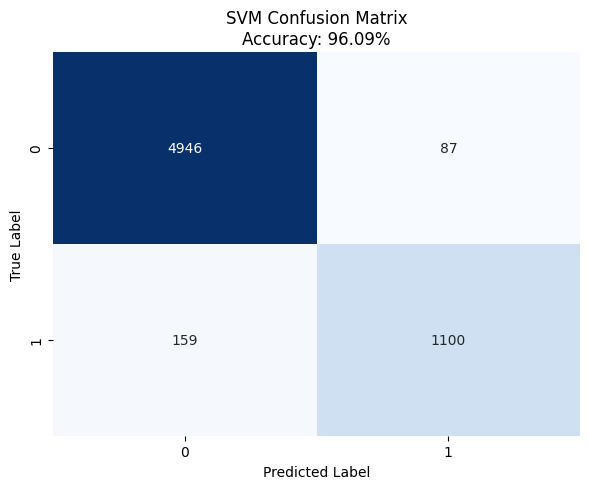

SVM Confusion Matrix saved to 'reports/figures/svm_confusion_matrix.png'

ROC-AUC Score (Target='ai'): 0.9848

SVM Model and Scaler saved to 'models/' directory.


In [8]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib

# 1. Feature Scaling (Crucial for SVM)
# --------------------------------------------------------
print("1. Performing Standard Scaling...")
scaler = StandardScaler()

# Fit scaler on Training Set only to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train_num)

# Apply transformation to Validation and Test sets (without re-fitting)
X_val_scaled = scaler.transform(X_val_num)
X_test_scaled = scaler.transform(X_test_num) # Prepared for final testing

print("Scaling complete.")


# 2. Model Training (SVM)
# --------------------------------------------------------
print("\n2. Training SVM model (this may take a few minutes)...")

# Model Parameters:
# - C=1.0: Standard trade-off between accuracy and generalization
# - kernel='rbf': Best for complex, non-linear data
# - probability=True: Required for ROC-AUC calculation
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    probability=True,
    random_state=42,
    cache_size=2000,
    verbose=True
)

start_time = time.time()
svm_model.fit(X_train_scaled, y_train)
end_time = time.time()

training_time = (end_time - start_time) / 60
print(f"Model trained successfully in {training_time:.2f} minutes.")


# 3. Evaluation on Validation Set
# --------------------------------------------------------
print("\n3. Evaluating results on Validation Set...")

# Predict class labels
val_pred = svm_model.predict(X_val_scaled)

# CRITICAL FIX: Use Index 0 for 'ai' probability
# Classes are sorted alphabetically: ['ai', 'human']
# Index 0 = Probability of AI
val_proba = svm_model.predict_proba(X_val_scaled)[:, 0]

# A. Classification Report
acc = accuracy_score(y_val, val_pred)
print(f"\nAccuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_val, val_pred))

# B. Confusion Matrix Visualization & Saving
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'SVM Confusion Matrix\nAccuracy: {acc:.2%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('reports/figures/svm_confusion_matrix.png')
plt.show()
print("SVM Confusion Matrix saved to 'reports/figures/svm_confusion_matrix.png'")

# C. Calculate ROC-AUC
try:
    # We define 'ai' as the Positive Class (1) for this metric
    y_val_binary = (y_val == "ai").astype(int)

    # Now we compare "True AI Labels" (1) against "Probability of AI"
    auc_score = roc_auc_score(y_val_binary, val_proba)
    print(f"\nROC-AUC Score (Target='ai'): {auc_score:.4f}")
except ValueError:
    print("\nCould not calculate ROC-AUC (Check label format).")


# 4. Save Model to Disk
# --------------------------------------------------------
joblib.dump(svm_model, 'models/svm_model_final.pkl')
joblib.dump(scaler, 'models/scaler_final.pkl')
print("\nSVM Model and Scaler saved to 'models/' directory.")

Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   10.0s finished


Random Forest trained in 10.08 seconds.


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s


Random Forest Performance (Validation Set):
              precision    recall  f1-score   support

          ai       0.99      0.99      0.99      5033
       human       0.94      0.97      0.96      1259

    accuracy                           0.98      6292
   macro avg       0.97      0.98      0.97      6292
weighted avg       0.98      0.98      0.98      6292



[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


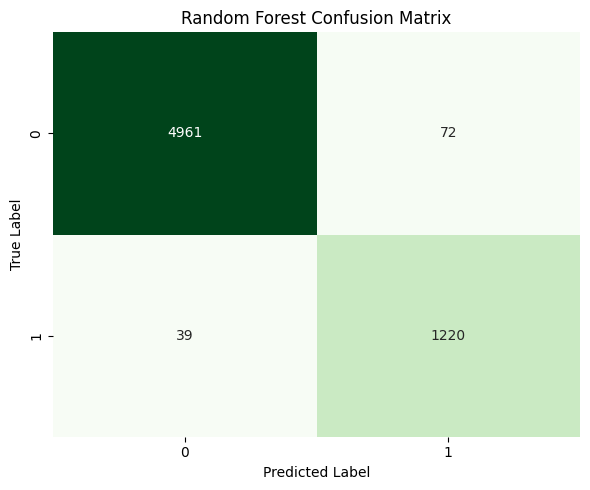

Confusion Matrix saved to 'reports/figures/rf_confusion_matrix.png'
ROC-AUC Score (Target='ai'): 0.9952
Random Forest model saved to 'models/rf_model_final.pkl'


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# 1. Initialize Random Forest Model
# ---------------------------------------------------------
# - n_estimators=200: Uses 200 trees for robust predictions.
# - class_weight='balanced': Adjusts weights inversely to class frequencies.
# - n_jobs=-1: Uses all available CPU cores for parallel processing.
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 2. Train Model
# ---------------------------------------------------------
print("Training Random Forest model...")
start_time = time.time()
rf_model.fit(X_train_num, y_train)
end_time = time.time()

print(f"Random Forest trained in {(end_time - start_time):.2f} seconds.")

# 3. Evaluate on Validation Set
# ---------------------------------------------------------
val_pred_rf = rf_model.predict(X_val_num)

# CRITICAL FIX: Use Index 0 for 'ai' probability
# Classes are sorted alphabetically: ['ai', 'human']
# Index 0 = Probability of AI
val_proba_rf = rf_model.predict_proba(X_val_num)[:, 0]

print("Random Forest Performance (Validation Set):")
print(classification_report(y_val, val_pred_rf))

# A. Confusion Matrix Visualization & Saving
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, val_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('reports/figures/rf_confusion_matrix.png')
plt.show()
print("Confusion Matrix saved to 'reports/figures/rf_confusion_matrix.png'")

# B. Calculate ROC-AUC
try:
    # We define 'ai' as the Positive Class (1) for this metric
    y_val_binary = (y_val == "ai").astype(int)

    # Now we compare "True AI Labels" (1) against "Probability of AI"
    auc_rf = roc_auc_score(y_val_binary, val_proba_rf)
    print(f"ROC-AUC Score (Target='ai'): {auc_rf:.4f}")
except Exception as e:
    print(f"Could not calculate ROC-AUC: {e}")

# 4. Save Model to Disk
# ---------------------------------------------------------
joblib.dump(rf_model, 'models/rf_model_final.pkl')
print("Random Forest model saved to 'models/rf_model_final.pkl'")

Analyzing Feature Importance...


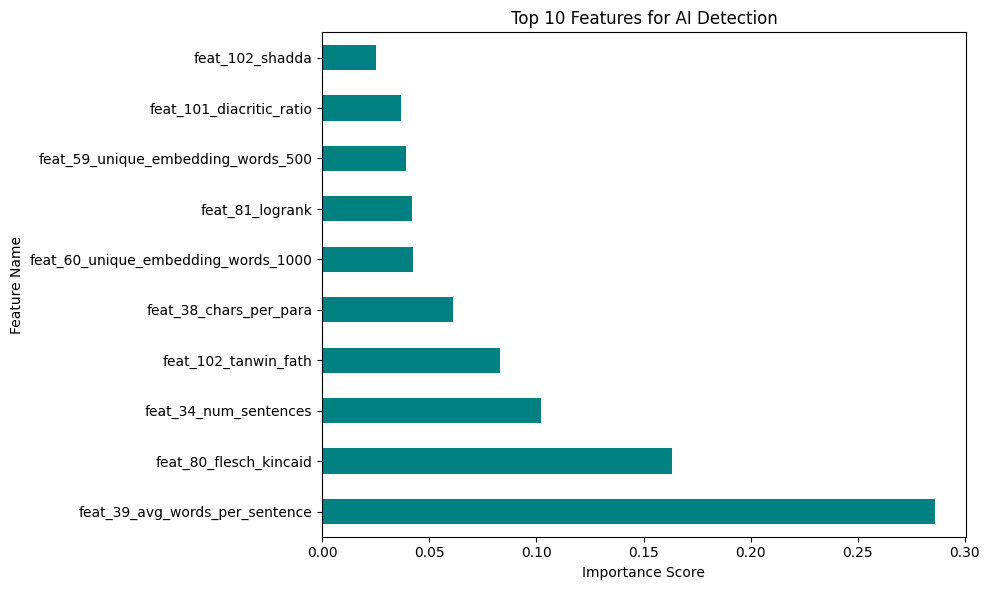

Feature Importance plot saved to 'reports/figures/rf_feature_importance.png'


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Importance Analysis
# ---------------------------------------------------------
print("Analyzing Feature Importance...")

# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train_num.columns

# Convert to Series for easier plotting
feat_importances = pd.Series(importances, index=feature_names)

# 2. Visualize Top 10 Features
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Select and plot the top 10 most influential features
feat_importances.nlargest(10).plot(kind='barh', color='teal')

plt.title("Top 10 Features for AI Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()

# 3. Save Figure
# ---------------------------------------------------------
output_path = 'reports/figures/rf_feature_importance.png'
plt.savefig(output_path)
plt.show()

print(f"Feature Importance plot saved to '{output_path}'")

In [11]:
# Install necessary libraries for BERT (Deep Learning)
# Using '!' allows this to run directly in Jupyter/Colab environments
!pip install -q transformers datasets accelerate scikit-learn

import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder

# 1. Data Preparation for BERT
# ---------------------------------------------------------
print("Preparing Data for BERT Training...")

# Encode string labels ('human', 'ai') into integers (0, 1)
# BERT requires numeric labels for the loss function.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# Display the mapping to confirm correct encoding
# Expected: {'ai': 0, 'human': 1}
print(f"Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2. Select Pre-trained Model
# ---------------------------------------------------------
# We use 'aubmindlab/bert-base-arabertv02', a model pre-trained specifically
# on large Arabic corpora, offering superior performance over multilingual models.
model_name = 'aubmindlab/bert-base-arabertv02'
tokenizer = BertTokenizer.from_pretrained(model_name)

# 3. Define Custom Dataset Class
# ---------------------------------------------------------
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # Tokenize text with padding and truncation
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 4. Create Dataset Objects
# ---------------------------------------------------------
# Ensure we pass the raw text list and the encoded numeric labels
train_dataset = TextDataset(X_train['text'].tolist(), y_train_encoded, tokenizer)
val_dataset = TextDataset(X_val['text'].tolist(), y_val_encoded, tokenizer)

print("Data tokenization complete. Ready for training.")

Preparing Data for BERT Training...
Label Mapping: {'ai': np.int64(0), 'human': np.int64(1)}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Data tokenization complete. Ready for training.


In [12]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Define Metric Computation Function
# ---------------------------------------------------------
# This function is called at the end of each evaluation epoch.
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate Precision, Recall, and F1-Score
    # CRITICAL: 'pos_label=0' ensures we calculate metrics for the 'AI' class (mapped to 0)
    # This aligns with our fixes in SVM/RF to prioritize AI detection.
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', pos_label=0
    )

    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 2. Initialize Model
# ---------------------------------------------------------
# Load the pre-trained AraBERT model with a classification head (2 labels)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 3. Define Training Arguments
# ---------------------------------------------------------
# We specify where to save the model and how the training should proceed.
training_args = TrainingArguments(
    output_dir='models/bert_fine_tuned',  # Save checkpoints to the 'models' folder
    logging_dir='models/bert_logs',       # Save training logs here

    num_train_epochs=3,                   # 3 Epochs is usually sufficient for fine-tuning
    per_device_train_batch_size=16,       # Standard batch size for Colab GPUs
    per_device_eval_batch_size=32,

    warmup_steps=500,                     # Warmup helps stabilize early training
    weight_decay=0.01,                    # Regularization to prevent overfitting

    eval_strategy="epoch",                # Evaluate validation set at the end of each epoch
    save_strategy="epoch",                # Save model checkpoint at the end of each epoch
    load_best_model_at_end=True,          # Automatically load the best epoch at the end

    logging_steps=100,
    fp16=True,                            # Use Mixed Precision (faster training on GPU)
    report_to="none"                      # Disable external reporting tools (WandB, etc.)
)

# 4. Initialize Trainer
# ---------------------------------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Trainer initialized. Configuration set to save to 'models/bert_fine_tuned'.")

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainer initialized. Configuration set to save to 'models/bert_fine_tuned'.


Starting BERT Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.058900,0.038762,0.993484,0.995927,0.995828,0.996026
2,0.013700,0.029729,0.993802,0.996126,0.996027,0.996225
3,0.015400,0.029409,0.994596,0.996619,0.997611,0.995629


Training complete.
BERT model and tokenizer saved to 'models/bert_fine_tuned'.


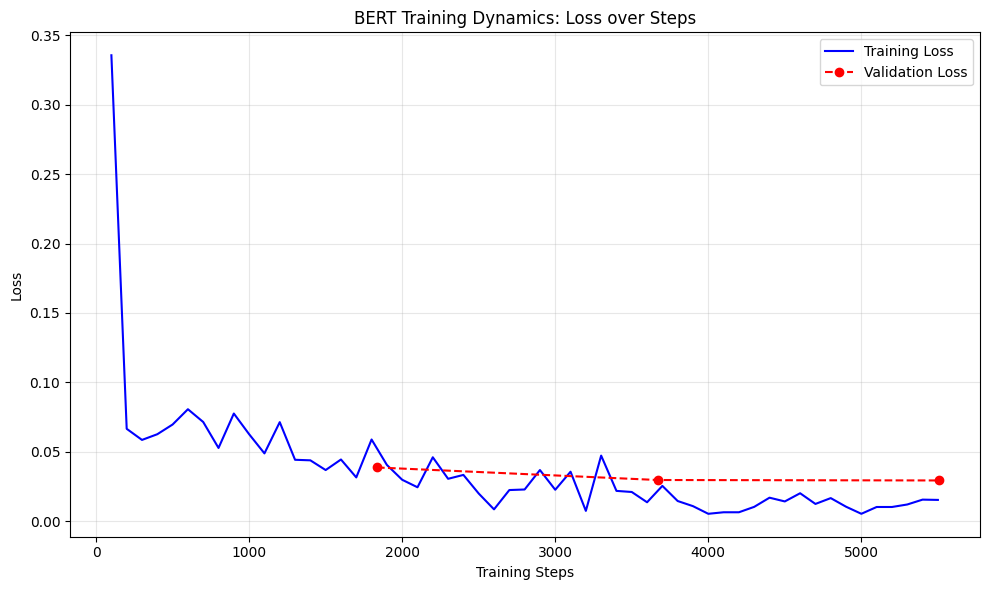

Training loss plot saved to 'reports/figures/bert_training_loss.png'


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Start Training
# ---------------------------------------------------------
print("Starting BERT Training...")
# This starts the fine-tuning process.
# Progress bars will appear below.
train_result = trainer.train()

print("Training complete.")

# 2. Save Final Model
# ---------------------------------------------------------
# We save the model and tokenizer to the 'models/' directory.
# This allows you to reload this specific trained model later without retraining.
output_model_dir = "models/bert_fine_tuned"
trainer.save_model(output_model_dir)
tokenizer.save_pretrained(output_model_dir)
print(f"BERT model and tokenizer saved to '{output_model_dir}'.")

# 3. Visualize & Save Training History
# ---------------------------------------------------------
# We extract the logs to plot Training Loss vs. Validation Loss.
# This graph is essential for the "Results" section of your report.

# Convert log history to DataFrame
history = pd.DataFrame(trainer.state.log_history)

# Separate training loss and validation loss
# (Trainer logs them in different rows at different steps)
train_history = history[history['loss'].notna()][['step', 'loss']]
eval_history = history[history['eval_loss'].notna()][['step', 'eval_loss']]

if not train_history.empty and not eval_history.empty:
    plt.figure(figsize=(10, 6))

    # Plot Training Loss
    plt.plot(train_history['step'], train_history['loss'], label='Training Loss', color='blue')

    # Plot Validation Loss
    plt.plot(eval_history['step'], eval_history['eval_loss'], label='Validation Loss', color='red', linestyle='--', marker='o')

    plt.title('BERT Training Dynamics: Loss over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save Plot
    save_path = 'reports/figures/bert_training_loss.png'
    plt.savefig(save_path)
    plt.show()
    print(f"Training loss plot saved to '{save_path}'")
else:
    print("Insufficient log data to generate loss plot.")

Generating BERT predictions for Validation Set...



--- Validation Set Leaderboard ---


,Accuracy,F1-Score (AI)
Model,,
BERT,0.994596,0.996619
Random Forest,0.982359,0.988937
SVM,0.960903,0.975735


Metrics saved to 'reports/metrics_summary.txt'


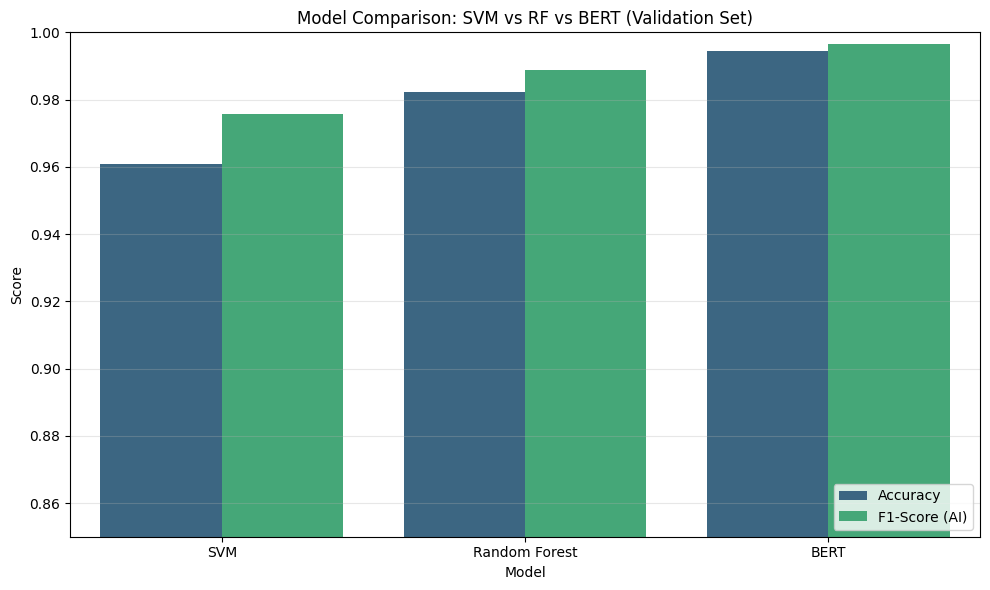

Comparison plot saved to 'reports/figures/model_comparison_leaderboard.png'


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# 1. Retrieve BERT Predictions
# ---------------------------------------------------------
print("Generating BERT predictions for Validation Set...")
# We use the trainer to get raw predictions on the validation dataset
preds_output = trainer.predict(val_dataset)
y_pred_bert = preds_output.predictions.argmax(-1)

# 2. Compile Leaderboard
# ---------------------------------------------------------
# We compare the 3 models based on Accuracy and F1-Score.
# Note: For F1-Score, we strictly target the 'AI' class to see which model is best at detection.
# - SVM/RF use string labels ('ai'/'human') -> pos_label='ai'
# - BERT uses encoded labels (0/1) -> pos_label=0 (which maps to 'ai')

models_scores = {
    'Model': ['SVM', 'Random Forest', 'BERT'],
    'Accuracy': [
        accuracy_score(y_val, val_pred),                   # SVM (val_pred from Cell 8)
        accuracy_score(y_val, val_pred_rf),                # Random Forest
        accuracy_score(y_val_encoded, y_pred_bert)         # BERT
    ],
    'F1-Score (AI)': [
        f1_score(y_val, val_pred, pos_label='ai'),         # SVM
        f1_score(y_val, val_pred_rf, pos_label='ai'),      # RF
        f1_score(y_val_encoded, y_pred_bert, pos_label=0)  # BERT
    ]
}

results_df = pd.DataFrame(models_scores).set_index('Model')

print("\n--- Validation Set Leaderboard ---")
display(results_df.sort_values(by='Accuracy', ascending=False))

# 3. Save Metrics to Text File
# ---------------------------------------------------------
# Saving the raw numbers to a text file for your report
metrics_path = 'reports/metrics_summary.txt'
with open(metrics_path, 'w') as f:
    f.write("Validation Set Performance Metrics\n")
    f.write("==================================\n\n")
    f.write(results_df.to_string())
print(f"Metrics saved to '{metrics_path}'")

# 4. Visualize Comparison
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Melt DataFrame for Seaborn plotting
results_melted = results_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison: SVM vs RF vs BERT (Validation Set)')
plt.ylim(0.85, 1.0) # Zoom in to show fine differences
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

# Save Plot
plot_path = 'reports/figures/model_comparison_leaderboard.png'
plt.savefig(plot_path)
plt.show()
print(f"Comparison plot saved to '{plot_path}'")

In [15]:
import pandas as pd
import numpy as np
import torch

# 1. Identify Prediction Errors
# ---------------------------------------------------------
print("Performing detailed error analysis on BERT predictions...")

# We reuse the predictions generated in the previous cell (preds_output)
# Access raw logits to calculate model confidence
raw_logits = preds_output.predictions
y_pred_bert = raw_logits.argmax(-1)
y_true_bert = val_dataset.labels

# Find indices where prediction does not match reality
error_mask = (y_pred_bert != y_true_bert)
error_indices = np.where(error_mask)[0]

print(f"Total Errors: {len(error_indices)} out of {len(y_true_bert)} samples")
print(f"Error Rate: {(len(error_indices)/len(y_true_bert))*100:.2f}%")

# 2. Compile Error Report
# ---------------------------------------------------------
error_records = []
val_texts = val_dataset.texts # Access original text stored in the dataset object

for idx in error_indices:
    # Convert numeric labels back to strings (Human/AI) for readability
    # Note: le is the LabelEncoder fitted in Cell 11
    true_label_str = le.inverse_transform([y_true_bert[idx]])[0]
    pred_label_str = le.inverse_transform([y_pred_bert[idx]])[0]

    # Calculate Confidence (Softmax)
    # We convert raw logits to probabilities to see how "confident" the model was in its mistake
    probs = torch.nn.functional.softmax(torch.tensor(raw_logits[idx]), dim=0)
    confidence = probs[y_pred_bert[idx]].item() * 100

    error_records.append({
        'Original_Text': val_texts[idx],
        'True_Label': true_label_str,
        'Predicted_Label': pred_label_str,
        'Confidence (%)': f"{confidence:.2f}%",
        'Text_Length': len(str(val_texts[idx]).split())
    })

# Convert to DataFrame
df_errors = pd.DataFrame(error_records)

# 3. Save Report to Disk (Mandatory Deliverable)
# ---------------------------------------------------------
output_csv = 'reports/bert_error_analysis.csv'
df_errors.to_csv(output_csv, index=False)
print(f"Error analysis report saved to '{output_csv}'")

# 4. Display Samples
# ---------------------------------------------------------
print("\nSample Errors:")
if not df_errors.empty:
    display(df_errors.head(5))
else:
    print("Congratulations! No errors found (100% Accuracy).")

Performing detailed error analysis on BERT predictions...
Total Errors: 34 out of 6292 samples
Error Rate: 0.54%
Error analysis report saved to 'reports/bert_error_analysis.csv'

Sample Errors:


,Original_Text,True_Label,Predicted_Label,Confidence (%),Text_Length
0,يهدف هذا البحث إلى رصد واقع اللغة العربية في ا...,ai,human,79.72%,113
1,تعتبر دراسة الطفولة ومراحلها المختلفة من العوا...,ai,human,99.76%,141
2,"ظهرت عبارة ""مبدأ المسؤوليات المشتركة ولكن المت...",human,ai,99.92%,127
3,تستعرض هذه الدراسة الميدانية تمظهرات الخطاب ال...,ai,human,95.72%,109
4,أدى التدهور البيئي الذي شهده العالم في العقود ...,human,ai,98.98%,84


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix

print("STARTING FINAL TEST SET EVALUATION...")
print("=====================================")

# 1. Prepare Test Data for BERT
# ---------------------------------------------------------
# Tokenize the test set
y_test_encoded = le.transform(y_test)
test_dataset = TextDataset(X_test['text'].tolist(), y_test_encoded, tokenizer)

# 2. Generate Predictions on Test Set
# ---------------------------------------------------------
print("Generating predictions for all models...")

# A. Logistic Regression (Baseline) - Uses Numeric Features
test_pred_log = log_model.predict(X_test_num)
test_proba_log = log_model.predict_proba(X_test_num)[:, 0] # Index 0 for AI

# B. SVM - Uses Scaled Numeric Features
test_pred_svm = svm_model.predict(X_test_scaled)
test_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 0] # Index 0 for AI

# C. Random Forest - Uses Numeric Features
test_pred_rf = rf_model.predict(X_test_num)
test_proba_rf = rf_model.predict_proba(X_test_num)[:, 0] # Index 0 for AI

# D. BERT - Uses Tokenized Text
test_preds_output = trainer.predict(test_dataset)
test_pred_bert = test_preds_output.predictions.argmax(-1)
# Calculate BERT probabilities (Softmax on logits)
test_logits_bert = torch.tensor(test_preds_output.predictions)
test_proba_bert = torch.nn.functional.softmax(test_logits_bert, dim=1)[:, 0].numpy() # Index 0 for AI


# 3. Final Leaderboard (Test Set)
# ---------------------------------------------------------
# Helper function to compile metrics
def get_metrics(y_true, y_pred, y_proba, model_name):
    # Ensure y_true is binary (0=AI, 1=Human) for ROC
    # If y_true is string, we map 'ai' to 0 and 'human' to 1
    if y_true.dtype == 'O':
        y_true_bin = (y_true == 'human').astype(int) # 0=ai, 1=human
        # wait, if our proba is for AI (0), we need y_true where AI is 1 for roc_auc_score?
        # Actually, sklearn roc_auc_score expects y_true and y_score to match direction.
        # Let's stick to our robust "AI vs Rest" logic:
        # Target: AI (0 or 'ai').
        y_true_ai = (y_true == 'ai') if y_true.dtype == 'O' else (y_true == 0)
        y_true_ai = y_true_ai.astype(int)
    else:
        y_true_ai = (y_true == 0).astype(int)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (AI)': precision_score(y_true, y_pred, pos_label='ai' if y_true.dtype=='O' else 0),
        'Recall (AI)': recall_score(y_true, y_pred, pos_label='ai' if y_true.dtype=='O' else 0),
        'F1-Score (AI)': f1_score(y_true, y_pred, pos_label='ai' if y_true.dtype=='O' else 0),
        'ROC-AUC (AI)': roc_auc_score(y_true_ai, y_proba)
    }

# Compile all results
metrics_list = [
    get_metrics(y_test, test_pred_log, test_proba_log, 'Logistic Regression'),
    get_metrics(y_test, test_pred_svm, test_proba_svm, 'SVM'),
    get_metrics(y_test, test_pred_rf, test_proba_rf, 'Random Forest'),
    get_metrics(y_test_encoded, test_pred_bert, test_proba_bert, 'BERT')
]

final_df = pd.DataFrame(metrics_list).set_index('Model')

print("\nFINAL TEST SET RESULTS:")
display(final_df.sort_values(by='Accuracy', ascending=False))

# Save Metrics
final_df.to_csv('reports/final_test_metrics.csv')
print("Saved final metrics to 'reports/final_test_metrics.csv'")


# 4. Visualize & Save Confusion Matrices (All Models)
# ---------------------------------------------------------
print("\nSaving Confusion Matrices for all models...")

models_data = [
    ('Logistic Regression', y_test, test_pred_log),
    ('SVM', y_test, test_pred_svm),
    ('Random Forest', y_test, test_pred_rf),
    ('BERT', y_test_encoded, test_pred_bert)
]

for name, true_y, pred_y in models_data:
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(true_y, pred_y)

    # Handle labels: String ('ai', 'human') vs Int (0, 1)
    labels = ['AI', 'Human']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save
    filename = f"reports/figures/cm_{name.replace(' ', '_').lower()}.png"
    plt.savefig(filename)
    plt.close() # Close plot to avoid cluttering notebook output
    print(f"Saved: {filename}")

print("\n PROJECT COMPLETE. ALL DELIVERABLES GENERATED.")

STARTING FINAL TEST SET EVALUATION...
Generating predictions for all models...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished



FINAL TEST SET RESULTS:


,Accuracy,Precision (AI),Recall (AI),F1-Score (AI),ROC-AUC (AI)
Model,,,,,
BERT,0.996344,0.998012,0.997417,0.997714,0.999407
Random Forest,0.985853,0.993610,0.988675,0.991136,0.995357
SVM,0.957717,0.965618,0.982118,0.973798,0.984617
Logistic Regression,0.944524,0.977959,0.952116,0.964865,0.979608


Saved final metrics to 'reports/final_test_metrics.csv'

Saving Confusion Matrices for all models...
Saved: reports/figures/cm_logistic_regression.png
Saved: reports/figures/cm_svm.png
Saved: reports/figures/cm_random_forest.png
Saved: reports/figures/cm_bert.png

 PROJECT COMPLETE. ALL DELIVERABLES GENERATED.


In [17]:
import os

# 1. Define Content for 'src/modeling.py'
# ---------------------------------------------------------
# We write the model training logic into a reusable Python script.
# This fulfills the 'Source Code' deliverable requirement.

script_content = """
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

class ModelTrainer:
    def __init__(self, random_state=42):
        self.random_state = random_state

    def train_logistic_regression(self, X_train, y_train):
        print("Training Logistic Regression (Baseline)...")
        model = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            n_jobs=-1,
            random_state=self.random_state
        )
        model.fit(X_train, y_train)
        print("Logistic Regression training complete.")
        return model

    def train_svm(self, X_train, y_train, C=1.0, kernel='rbf'):
        print(f"Training SVM (C={C}, kernel={kernel})...")
        model = SVC(
            C=C,
            kernel=kernel,
            probability=True,
            random_state=self.random_state,
            cache_size=2000
        )
        model.fit(X_train, y_train)
        print("SVM training complete.")
        return model

    def train_random_forest(self, X_train, y_train, n_estimators=200):
        print(f"Training Random Forest (n_estimators={n_estimators})...")
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            class_weight='balanced',
            random_state=self.random_state,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        print("Random Forest training complete.")
        return model

    def evaluate_model(self, model, X_val, y_val):
        print("Evaluating model...")
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        print(f"Accuracy: {acc:.4f}")
        print(classification_report(y_val, preds))
        return acc

    def save_model(self, model, filepath):
        joblib.dump(model, filepath)
        print(f"Model saved to {filepath}")

if __name__ == "__main__":
    print("This module provides model training utilities.")
    print("Import this file to use the ModelTrainer class.")
"""

# 2. Write File to Disk
# ---------------------------------------------------------
output_path = 'src/modeling.py'
with open(output_path, "w") as f:
    f.write(script_content)

print(f"Source code script generated: {output_path}")
print("Project source code structure is now complete.")

Source code script generated: src/modeling.py
Project source code structure is now complete.


In [18]:
import zipfile
import os

# 1. Define Deliverables to Zip
# ---------------------------------------------------------
# We strictly select only the required folders and files for submission.
deliverables = [
    'data/processed',
    'models',
    'reports',
    'src',
    'requirements.txt'
]

output_filename = 'Project_Submission_Deliverables.zip'

print(f"Zipping deliverables to '{output_filename}'...")

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for item in deliverables:
        if os.path.isdir(item):
            # If it's a directory, walk through it and add all files
            for root, dirs, files in os.walk(item):
                # Exclude hidden folders/files
                dirs[:] = [d for d in dirs if not d.startswith('.')]

                for file in files:
                    if not file.startswith('.'):
                        file_path = os.path.join(root, file)
                        # Archive name should match the folder structure
                        zipf.write(file_path, arcname=file_path)
                        print(f"  Added: {file_path}")
        elif os.path.isfile(item):
            # If it's a single file, add it directly
            zipf.write(item, arcname=item)
            print(f"  Added: {item}")
        else:
            print(f"  Warning: '{item}' not found. Make sure previous cells ran successfully.")

print(f"\n✅ Successfully created '{output_filename}'.")
print("Download this file to submit your project.")

# Trigger download in Colab
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    pass

Zipping deliverables to 'Project_Submission_Deliverables.zip'...
  Added: data/processed/val_labels.xlsx
  Added: data/processed/test_labels.xlsx
  Added: data/processed/train_features.xlsx
  Added: data/processed/val_features.xlsx
  Added: data/processed/train_labels.xlsx
  Added: data/processed/Final_Engineered_Dataset.xlsx
  Added: data/processed/test_features.xlsx
  Added: models/rf_model_final.pkl
  Added: models/svm_model_final.pkl
  Added: models/scaler_final.pkl
  Added: models/bert_fine_tuned/special_tokens_map.json
  Added: models/bert_fine_tuned/vocab.txt
  Added: models/bert_fine_tuned/config.json
  Added: models/bert_fine_tuned/training_args.bin
  Added: models/bert_fine_tuned/model.safetensors
  Added: models/bert_fine_tuned/tokenizer_config.json
  Added: models/bert_fine_tuned/checkpoint-1835/trainer_state.json
  Added: models/bert_fine_tuned/checkpoint-1835/rng_state.pth
  Added: models/bert_fine_tuned/checkpoint-1835/scheduler.pt
  Added: models/bert_fine_tuned/checkpo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>